In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [74]:
train=pd.read_csv('/content/train.csv')
test=pd.read_csv('/content/test.csv')

In [75]:
test.columns

Index(['id', 'RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2',
       'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY',
       'ROLE_CODE'],
      dtype='object')

In [76]:
train.columns

Index(['ACTION', 'RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2',
       'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY',
       'ROLE_CODE'],
      dtype='object')

In [77]:
test_id = test["id"].copy()
test_features = test.drop(columns=["id"])   # remove Id for model
test=test.drop(columns=['id'])
test_id

,id
0,1
1,2
2,3
3,4
4,5
...,...
58916,58917
58917,58918
58918,58919
58919,58920


In [78]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32769 entries, 0 to 32768
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ACTION            32769 non-null  int64
 1   RESOURCE          32769 non-null  int64
 2   MGR_ID            32769 non-null  int64
 3   ROLE_ROLLUP_1     32769 non-null  int64
 4   ROLE_ROLLUP_2     32769 non-null  int64
 5   ROLE_DEPTNAME     32769 non-null  int64
 6   ROLE_TITLE        32769 non-null  int64
 7   ROLE_FAMILY_DESC  32769 non-null  int64
 8   ROLE_FAMILY       32769 non-null  int64
 9   ROLE_CODE         32769 non-null  int64
dtypes: int64(10)
memory usage: 2.5 MB


In [79]:
train.describe()

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
count,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000
mean,0.942110,42923.916171,25988.957979,116952.627788,118301.823156,118912.779914,125916.152644,170178.369648,183703.408893,119789.430132
std,0.233539,34173.892702,35928.031650,10875.563591,4551.588572,18961.322917,31036.465825,69509.462130,100488.407413,5784.275516
min,0.000000,0.000000,25.000000,4292.000000,23779.000000,4674.000000,117879.000000,4673.000000,3130.000000,117880.000000
25%,1.000000,20299.000000,4566.000000,117961.000000,118102.000000,118395.000000,118274.000000,117906.000000,118363.000000,118232.000000
50%,1.000000,35376.000000,13545.000000,117961.000000,118300.000000,118921.000000,118568.000000,128696.000000,119006.000000,118570.000000
75%,1.000000,74189.000000,42034.000000,117961.000000,118386.000000,120535.000000,120006.000000,235280.000000,290919.000000,119348.000000
max,1.000000,312153.000000,311696.000000,311178.000000,286791.000000,286792.000000,311867.000000,311867.000000,308574.000000,270691.000000


In [80]:
train.nunique()

,0
ACTION,2
RESOURCE,7518
MGR_ID,4243
ROLE_ROLLUP_1,128
ROLE_ROLLUP_2,177
ROLE_DEPTNAME,449
ROLE_TITLE,343
ROLE_FAMILY_DESC,2358
ROLE_FAMILY,67
ROLE_CODE,343


In [81]:
train[:5]

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


In [82]:
train.isnull().sum()

,0
ACTION,0
RESOURCE,0
MGR_ID,0
ROLE_ROLLUP_1,0
ROLE_ROLLUP_2,0
ROLE_DEPTNAME,0
ROLE_TITLE,0
ROLE_FAMILY_DESC,0
ROLE_FAMILY,0
ROLE_CODE,0


In [83]:
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score,train_test_split,cross_val_predict
from sklearn.metrics import roc_auc_score,roc_curve,precision_recall_curve,f1_score,precision_score,recall_score

X=train.copy()
X=X.drop(columns=['ACTION'])
y=train['ACTION'].copy()

x_train,x_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)


In [84]:
y_train.value_counts(normalize=True)

,proportion
ACTION,
1,0.941713
0,0.058287


As you can see, class 1 is heavily dominant. To address this, you might consider techniques like:

*   **Resampling methods:** Undersampling the majority class, oversampling the minority class (e.g., SMOTE), or a combination of both.
*   **Changing evaluation metrics:** While ROC AUC is generally good, for imbalanced data, metrics like Precision-Recall AUC (AUPRC), F1-score, or inspecting precision/recall curves might give a more insightful view of model performance, especially on the minority class.
*   **Using different algorithms or adjusting model parameters:** Some algorithms handle imbalance better, or you can use `class_weight` parameters in models like `SGDClassifier` or `SVC` (if available and applicable) to give more importance to the minority class.

In [85]:
x_train[:5]

,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
8476,34950,8433,117961,118327,118929,118321,117906,290919,118322
30814,23990,5244,117961,118343,119598,119433,133686,118424,119435
2332,18394,818,117961,118300,123719,118784,240983,290919,118786
32461,75834,5456,117961,118225,118403,118321,118448,290919,118322
20478,4675,16974,117961,118300,119181,117905,117906,290919,117908


In [86]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

def plot_pr(precision,recall,threshold,best_threshold=None):
  plt.plot(threshold,precision[:-1],"b--",label="Precision",linewidth=2)
  plt.plot(threshold,recall[:-1],"g-",label='Recall',linewidth=2)
  if not best_threshold:
    plt.vlines(best_threshold,0,1.0,"k","dotted",label="threshold")
  plt.xlabel("Threshold")
  plt.ylabel("Score")
  plt.title("Precision and Recall vs. Threshold")
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.7) # Added a standard grid
  plt.show()

def plot_roc(fpr,tpr):
  plt.plot(fpr,tpr,linewidth=2,label="Roc curve")
  plt.plot([0,1],[0,1],'k:',label="Random Clssifier's ROC curve")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.7) # Added a standard grid
  plt.show()

In [87]:
# pip install category_encoders
# from category_encoders import TargetEncoder


In [88]:
col_name=list(x_train.columns)
col_name

['RESOURCE',
 'MGR_ID',
 'ROLE_ROLLUP_1',
 'ROLE_ROLLUP_2',
 'ROLE_DEPTNAME',
 'ROLE_TITLE',
 'ROLE_FAMILY_DESC',
 'ROLE_FAMILY',
 'ROLE_CODE']

### Use target encoder

### F1 score take hard label
### ROC curve take probability not hard label

In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LogisticRegression

cols = col_name

preprocessor = ColumnTransformer(
    transformers=[
        ("target_enc", TargetEncoder(), cols)
    ],
    remainder='drop'
)


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



### Forest with roc auc score 0.815

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


In [91]:
pipeline_forest = Pipeline([
    ("preprocess", preprocessor),
    ("forest", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])


In [92]:
param_dist_rf = {
    "forest__n_estimators": [200, 400, 600],
    "forest__max_depth": [8, 12, 16, None],
    "forest__min_samples_split": [2, 5, 10],
    "forest__min_samples_leaf": [1, 3, 5],
    "forest__max_features": ["sqrt", "log2"],
    "forest__bootstrap": [True, False],
    "forest__class_weight": ["balanced"]
}

random_search_rf = RandomizedSearchCV(
    estimator=pipeline_forest,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="roc_auc",
    cv=kf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_rf.fit(x_train, y_train)

print("Best Score:", random_search_rf.best_score_)
print("Best Params:", random_search_rf.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Score: 0.8395783083293086
Best Params: {'forest__n_estimators': 200, 'forest__min_samples_split': 2, 'forest__min_samples_leaf': 5, 'forest__max_features': 'log2', 'forest__max_depth': 16, 'forest__class_weight': 'balanced', 'forest__bootstrap': True}


In [93]:


pipeline_forest = random_search_rf.best_estimator_


scores_forest = cross_val_score(
    pipeline_forest,
    x_train,
    y_train,
    cv=kf,
    scoring="roc_auc",
    n_jobs=-1
)

print(scores_forest.mean())


y_prob_forest = cross_val_predict(
    pipeline_forest,
    x_train,
    y_train,
    cv=kf,
    method="predict_proba",
    n_jobs=-1
)

y_prob_forest = y_prob_forest[:, 1]


0.8359519486353084


In [94]:
scores_forest.mean()

np.float64(0.8359519486353084)

In [95]:
y_pred_forest=y_prob_forest>=0.5

In [96]:
y_train[:3]

,ACTION
8476,1
30814,1
2332,0


In [97]:
y_prob_forest=y_prob_forest

In [98]:
y_pred_forest

array([ True,  True,  True, ...,  True,  True, False])

In [99]:
roc_auc_score(y_train,y_prob_forest)

np.float64(0.8398078365216277)

In [100]:
f1_score(y_train,y_pred_forest)

0.9624648490035457

In [101]:
y_val_forest_proba=pipeline_forest.predict_proba(x_val)
y_val_forest_proba


array([[0.02629261, 0.97370739],
       [0.01954772, 0.98045228],
       [0.06238301, 0.93761699],
       ...,
       [0.11827578, 0.88172422],
       [0.04564437, 0.95435563],
       [0.10873954, 0.89126046]])

In [102]:
y_val_forest_proba=y_val_forest_proba[:,1]
roc_auc_score(y_val,y_val_forest_proba)

np.float64(0.8587462455061091)

In [103]:
preds_test=pipeline_forest.predict_proba(test)
preds_test[:5]

array([[0.71973426, 0.28026574],
       [0.02163217, 0.97836783],
       [0.1137211 , 0.8862789 ],
       [0.01985147, 0.98014853],
       [0.12200651, 0.87799349]])

In [104]:
submission = pd.DataFrame({
    'id': test_id,
    'ACTION': preds_test[:,1]
})
submission
submission.to_csv('submission.csv', index=False)

### SGDC with roc auc score 0.79

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of predicted probabilities for class 1 on the training set
plt.figure(figsize=(10, 6))
sns.histplot(y_prob_forest, bins=50, kde=True)
plt.title('Distribution of Predicted Probabilities (Class 1) on Training Set (Random Forest)')
plt.xlabel('Predicted Probability of Class 1')
plt.ylabel('Frequency')
plt.axvline(0.5, color='red', linestyle='--', label='Default 0.5 Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

If the histogram shows that most predicted probabilities are well above 0.5, then the model's `predict()` method (which uses this default threshold) will indeed predict '1' for almost all instances.

**To improve your Kaggle submission, consider these steps:**

1.  **Submit Probabilities instead of Hard Labels:** If the Kaggle competition evaluates on ROC AUC, you should submit the predicted probabilities for the positive class (class 1) rather than the hard labels. The ROC AUC metric directly uses these probabilities to assess ranking performance, which is generally more informative for imbalanced classification than hard label accuracy.

2.  **Tune Prediction Threshold (if hard labels are required):** If the competition *does* require hard labels, you would need to tune the threshold for converting probabilities to hard labels (instead of the default 0.5). You can use metrics like precision-recall curves to find a threshold that balances precision and recall for the minority class, or optimizes for a specific F1-score.

3.  **Re-evaluate `class_weight`:** While `RandomizedSearchCV` selected `None` for `class_weight` based on ROC AUC, if your model is predicting almost all '1's, it might be beneficial to explicitly use `class_weight='balanced'` in your Random Forest model or re-run the search with a stronger emphasis on `class_weight='balanced'` if a more balanced prediction is desired for the hard labels. The fact that the AUC is good with `class_weight=None` suggests the *ranking* of instances by probability is good, but the absolute probabilities themselves are skewed towards 1, causing `predict()` to be biased.

In [15]:
pipeline_sgdc = Pipeline([
    ("preprocess", preprocessor),
    ("sgdc", SGDClassifier(random_state=42))
])
scores_sgdc = cross_val_score(pipeline_sgdc, x_train, y_train, cv=kf, scoring="roc_auc")
scores_sgdc.mean()



np.float64(0.8395276712127118)

In [16]:
y_pred_sgdc=cross_val_predict(pipeline_sgdc,x_train,y_train,cv=kf,n_jobs=-1)

In [17]:
y_pred_sgdc

array([1, 1, 1, ..., 1, 1, 1])

In [18]:
precision_score(y_train,y_pred_sgdc)

0.9419803038399878

In [19]:
recall_score(y_train,y_pred_sgdc)

0.999635435654393

In [20]:
f1_score(y_train,y_pred_sgdc)

0.9699518522157807

In [21]:
y_scores = cross_val_predict(pipeline_sgdc,x_train,y_train,cv=3,method="decision_function")

In [22]:
fpr,tpr,thresholds = roc_curve(y_train,y_scores)
roc_auc_score(y_train,y_scores)

np.float64(0.7868566812513613)

### SVM with roc auc 0.81

In [ ]:
from sklearn.svm import SVC

pipeline_svm = Pipeline([
    ("preprocess", preprocessor),
    ("svm",SVC(random_state=42,probability=True,class_weight='balanced'))
])
scores_svm = cross_val_score(pipeline_sgdc, x_train, y_train, cv=kf, scoring="roc_auc")

y_prob_svm = cross_val_predict(pipeline_svm,x_train,y_train,cv=3,method='predict_proba')

In [ ]:
scores_svm.mean()

np.float64(0.8374831038537482)

In [ ]:
y_prob_svm[:3]

array([[0.02275304, 0.97724696],
       [0.02090281, 0.97909719],
       [0.02057281, 0.97942719]])

In [ ]:
y_pred_svm=y_prob_svm[:,1]>=0.5

In [ ]:
roc_auc_score(y_train,y_prob_svm[:,1])

np.float64(0.8126500726265621)

In [ ]:
f1_score(y_train,y_pred_svm)

0.9698613978177528

In [ ]:
precision,recall,thresholds_pr=precision_recall_curve(y_train,y_prob_svm[:,1])
f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
best_idx = f1.argmax()
best_threshold = thresholds_pr[best_idx]
best_threshold

np.float64(0.41360107457993917)

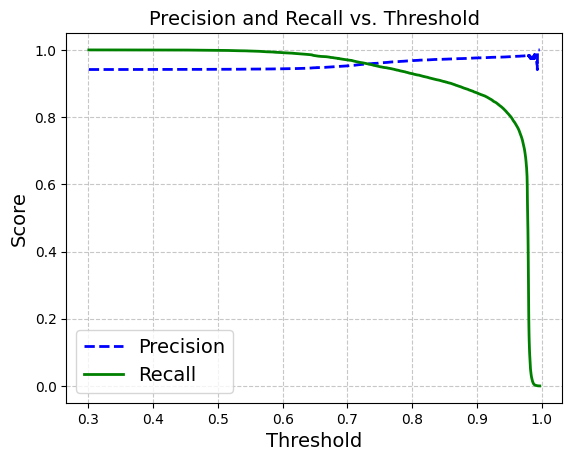

In [ ]:
plot_pr(precision,recall,thresholds_pr,best_threshold)

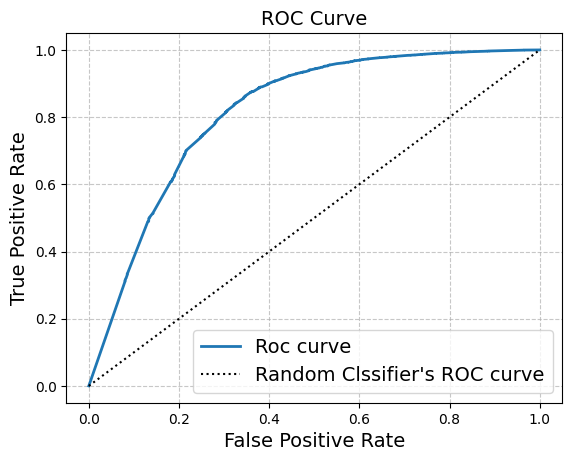

In [ ]:
# Forest
fpr,tpr,t=roc_curve(y_train,y_prob_forest)
plot_roc(fpr,tpr)

### Logistic regression with roc auc 0.55

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

In [ ]:
pipeline_LR = Pipeline([
    ("preprocess", preprocessor),
    ("lr", LogisticRegression(max_iter=1000))
])
scores_lr = cross_val_score(pipeline_LR, x_train, y_train, cv=kf, scoring="roc_auc")

y_prob_lgr=cross_val_predict(pipeline_LR,x_train,y_train,cv=5)
print(scores_lr.mean())


0.8362226073393991


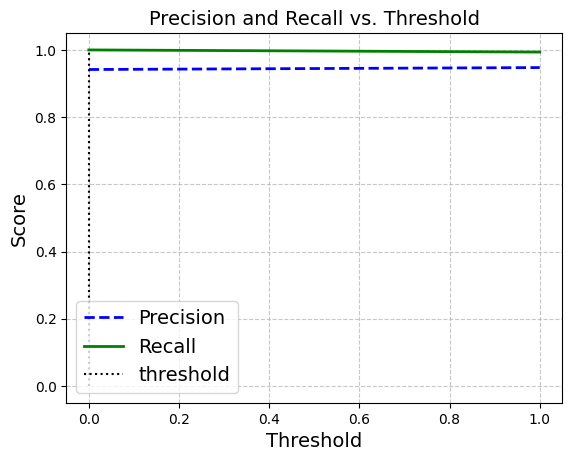

In [ ]:
p,r,t=precision_recall_curve(y_train,y_prob_lgr)
idx_85_pre=(p>=0.5).argmax()
y_threshold_85_precision=t[idx_85_pre]
plot_pr(p,r,t,y_threshold_85_precision)

In [ ]:
y_threshold_85_precision

np.int64(0)

In [ ]:
y_pred_lgr=(y_prob_lgr>=y_threshold_85_precision)

In [ ]:
f1_score(y_train,y_pred_lgr)

0.9699815331421162

In [ ]:
roc_auc_score(y_train,y_prob_lgr)

np.float64(0.5517737571780895)

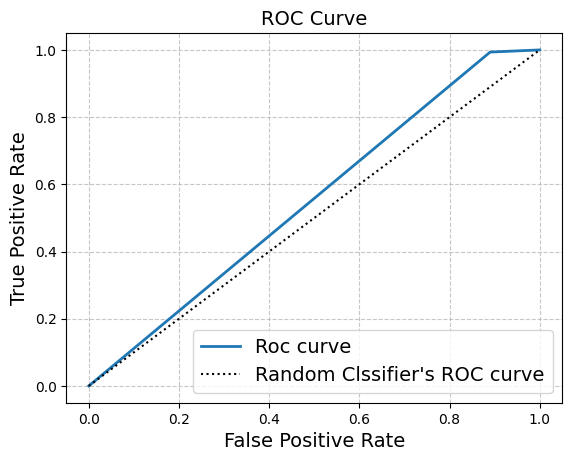

In [ ]:
fpr,tpr,t=roc_curve(y_train,y_prob_lgr)
plot_roc(fpr,tpr)

### Boosting

#### Catboost
  * No need to encode cataegorical(numerical or string) data

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

ratio = neg / pos
print(ratio)

0.06189492445416616


In [ ]:
import catboost
from catboost import CatBoostClassifier

cols=col_name

catboost = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    scale_pos_weight=float(ratio), # Changed to float(ratio)
    eval_metric='AUC',
    verbose=0)
scores = cross_val_score(catboost,x_train,y_train,cv=kf,scoring="roc_auc")

print(scores.mean())

0.8230360106473636


In [ ]:
y_prob_cat=cross_val_predict(catboost,x_train,y_train,cv=5,method="predict_proba")
roc_auc_score(y_train,y_prob_cat[:,1])

np.float64(0.8180802177291098)

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# param_dist = {
#     "iterations": [500, 800, 1200],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "depth": [6, 8, 10],
#     "l2_leaf_reg": [3, 5, 7],
#     "bagging_temperature": [0, 0.5, 1],
# }

# search = RandomizedSearchCV(
#     catboost,
#     param_distributions=param_dist,
#     n_iter=20,
#     scoring="roc_auc",
#     cv=kf,
#     verbose=1
# )

# search.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.1, scale_pos_weight=0.06189492445416616, verbose=0),
                   n_iter=20,
                   param_distributions={'bagging_temperature': [0, 0.5, 1],
                                        'depth': [6, 8, 10],
                                        'iterations': [500, 800, 1200],
                                        'l2_leaf_reg': [3, 5, 7],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1]},
                   scoring='roc_auc', verbose=1)

In [ ]:
cat_final=CatBoostClassifier(bagging_temperature=1, depth=8, eval_metric='AUC', iterations=800, l2_leaf_reg=5, learning_rate=0.05, scale_pos_weight=0.06189492445416616, verbose=0)

In [ ]:
# cat_final=search.best_estimator_
y_prob_cat=cross_val_predict(cat_final,x_train,y_train,cv=5,method="predict_proba")
roc_auc_score(y_train,y_prob_cat[:,1])

np.float64(0.8247849197608509)

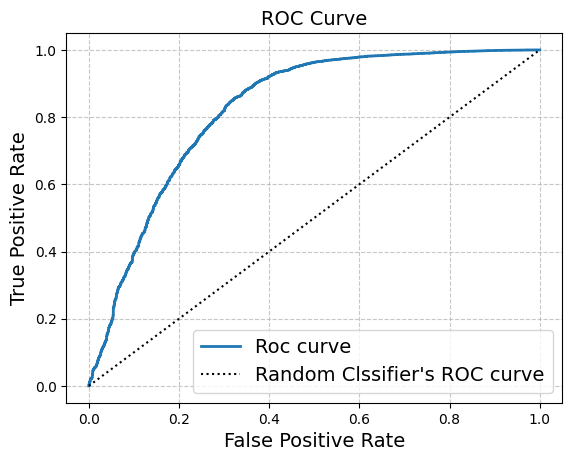

In [ ]:
fpr,tpr,t=roc_curve(y_train,y_prob_cat[:,1])
plot_roc(fpr,tpr)

In [ ]:
y_val_prob_cat=cross_val_predict(cat_final,x_val,y_val,cv=5,method="predict_proba")
roc_auc_score(y_val,y_val_prob_cat[:,1])

np.float64(0.7110887648892656)

In [ ]:
cat_final

CatBoostClassifier(bagging_temperature=1, depth=8, eval_metric='AUC', iterations=800, l2_leaf_reg=5, learning_rate=0.05, scale_pos_weight=0.06189492445416616, verbose=0)

#### XGBoost

In [36]:

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, cross_val_predict

# ================================
# 2. Compute imbalance weight
# ================================
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# ================================
# 3. Pipeline
# ================================
pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,   # 🔥 important
        random_state=42,
        n_jobs=-1
    ))
])

# ================================
# 4. Param Distribution (small + effective)
# ================================
param_dist_xgb = {
    "xgb__n_estimators": [300, 500, 700],
    "xgb__max_depth": [4, 6, 8],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__subsample": [0.7, 0.8, 1.0],
    "xgb__colsample_bytree": [0.7, 0.8, 1.0],
    "xgb__gamma": [0, 1, 5],
    "xgb__reg_lambda": [1, 5, 10]
}

# ================================
# 5. Random Search
# ================================
random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="roc_auc",
    cv=kf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# ================================
# 6. Fit
# ================================
random_search_xgb.fit(x_train, y_train)

print("Best Score:", random_search_xgb.best_score_)
print("Best Params:", random_search_xgb.best_params_)

# ================================
# 7. Use best model
# ================================
pipeline_xgb = random_search_xgb.best_estimator_

# ================================
# 8. CV Score
# ================================
scores_xgb = cross_val_score(
    pipeline_xgb,
    x_train,
    y_train,
    cv=kf,
    scoring="roc_auc",
    n_jobs=-1
)

print("Final CV AUC:", scores_xgb.mean())

# ================================
# 9. Out-of-fold predictions
# ================================
y_prob_xgb = cross_val_predict(
    pipeline_xgb,
    x_train,
    y_train,
    cv=kf,
    method="predict_proba",
    n_jobs=-1
)

y_prob_xgb = y_prob_xgb[:, 1]

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:13:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Score: 0.8470492851995569
Best Params: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 10, 'xgb__n_estimators': 700, 'xgb__max_depth': 8, 'xgb__learning_rate': 0.03, 'xgb__gamma': 5, 'xgb__colsample_bytree': 0.8}
Final CV AUC: 0.8468208850506656


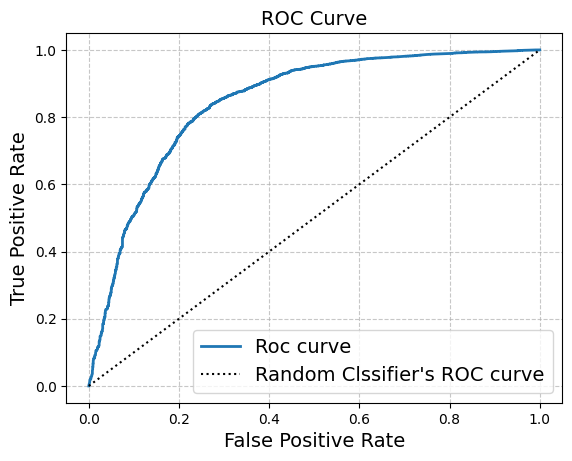

In [37]:
fpr,tpr,t=roc_curve(y_train,y_prob_xgb)
plot_roc(fpr,tpr)

In [44]:
y_val_xgb_proba=pipeline_xgb.predict_proba(x_val)
y_val_xgb_proba

array([[0.22720575, 0.77279425],
       [0.19900876, 0.80099124],
       [0.31076163, 0.68923837],
       ...,
       [0.14067698, 0.859323  ],
       [0.12781757, 0.8721824 ],
       [0.13637245, 0.86362755]], dtype=float32)

In [45]:
y_val_xgb_proba=y_val_xgb_proba[:,1]
roc_auc_score(y_val,y_val_xgb_proba)

np.float64(0.8506974431102438)